# Perturb-seq analysis (Python)

This tutorial uses an excitatory-neuron subset from [Jin et al. (2020), *Science*](https://doi.org/10.1126/science.aaz6063), which studied gene perturbations in the developing mouse brain. Data are available from the [Broad Single Cell Portal](https://singlecell.broadinstitute.org/single_cell/study/SCP1184).

The workflow is **prepare counts and treatment indicators → fit latent factors → check propensity support and refit where it fails → estimate log-fold changes**. Support is checked before the effects are read, because an arm whose weights concentrate can report a discovery count that reflects the weights rather than the biology. Saved outputs illustrate one run; counts and rankings may change after refitting.


In [1]:
import os 
import sys
sys.path.append('../../..')

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt

import scanpy as sc

from causarray import (
    prep_causarray_data, fit_gcate, LFC, estimate_propensity_scores,
    summarize_propensity_scores, plot_propensity_scores, refit_propensity_scores,
    summarize_treatment_associations, plot_treatment_associations,
)

## Load data

Load the preprocessed count subset from `data/perturbseq-exneu.h5ad`.


In [2]:
adata = sc.read_h5ad('data/perturbseq-exneu.h5ad')
adata

AnnData object with n_obs × n_vars = 2926 × 3221
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'NAME', 'nGene', 'nUMI', 'Cluster', 'Batch', 'CellType', 'Perturbation', 'isKey', 'isAnalysed', 'SCRUBLET'

## Prepare inputs

Use `Y` for cell-by-gene counts, `A` for perturbation indicators, and `X`/`X_A` for outcome/propensity covariates. GFP control cells have all-zero treatment indicators. `prep_causarray_data` prepares the designs, including an intercept and log-library size in the propensity model.


In [3]:
Y = pd.DataFrame(adata.X.copy(), columns=adata.var.index)
A = pd.get_dummies(adata.obs['Perturbation'], columns=['Perturbation'], drop_first=False).drop(columns=['GFP'])

Y, A, X, X_A = prep_causarray_data(Y, A)
a = A.shape[1]
a

29

### Number of latent factors

Inspect the cached JIC curve within the candidate range shown below. Smaller JIC values indicate the preferred fit under this criterion, but a flat curve means nearby ranks deserve checking. The fitting cell uses a fixed illustrative rank; changing the candidate range does not automatically update it or the factor-filtering examples.


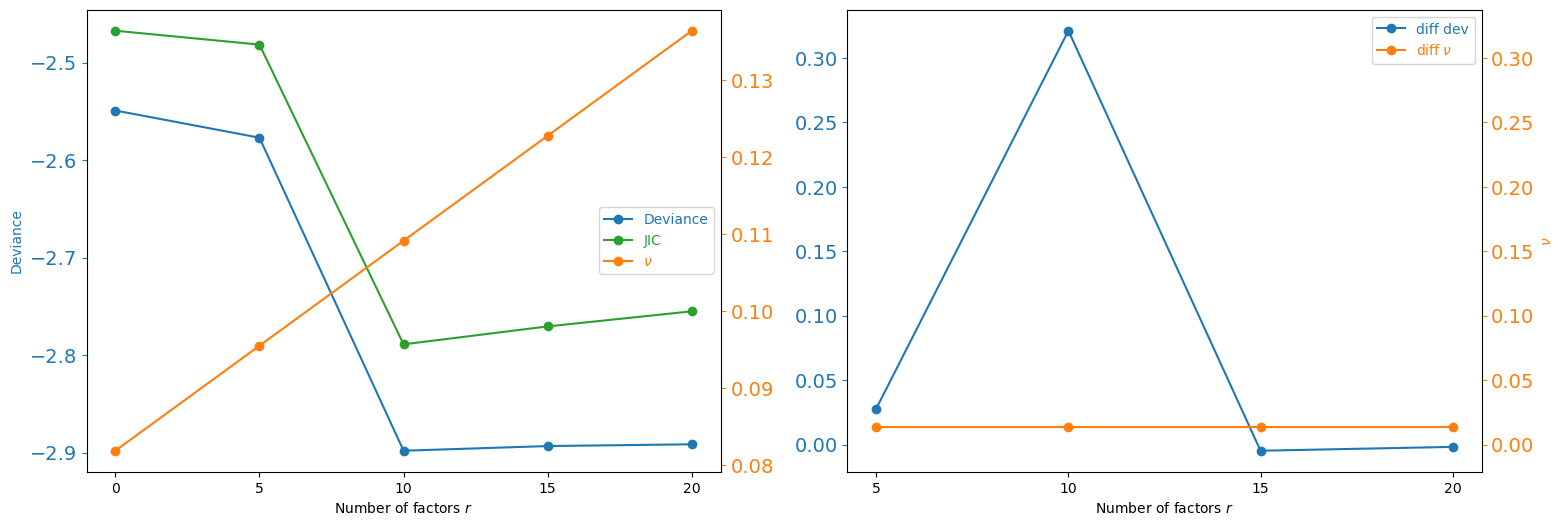

In [4]:
from causarray import estimate_r, plot_r
# df_r = estimate_r(Y, X, A, np.arange(5,55,5))
# df_r.to_csv('results/perturbseq-r.csv', index=False)
df_r = pd.read_csv('results/perturbseq-r.csv')
# Inspect a restricted candidate range; the fitting rank below is explicit.
df_r = df_r[df_r['r'] <= 20]
fig = plot_r(df_r)

### Estimate latent factors

GCATE represents shared expression variation with latent factors, which are appended to the outcome and propensity designs. Their interpretation as confounding adjustment depends on the model assumptions; the fit does not identify the biological source of each factor.


In [5]:
r = 10  # Illustrative rank; inspect the JIC curve and nearby ranks.
res_1, res_2 = fit_gcate(Y, X, A, r, verbose=True,
    kwargs_es_1=dict(rel_tol=2e-4, max_iters=30),
    kwargs_es_2=dict(rel_tol=2e-4, max_iters=30),
)
U = res_2['U']
print(f"\nStep 1  -- epochs: {res_1['n_iter']},  best NLL: {min(res_1['hist']):.6f}")
print(f"Step 2  -- epochs: {res_2['n_iter']},  best NLL: {min(res_2['hist']):.6f}")

{'d': 30, 'n': 2926, 'p': 3221, 'r': 10}
'Estimating initial latent variables with GLMs...'
'Fitting nb GLM (structured, 1 covariates + 29 treatments)...'


'Estimating initial coefficients with GLMs...'
'Fitting nb GLM (structured, 11 covariates + 29 treatments)...'


{'kwargs_es': {'max_iters': 30,
               'patience': 5,
               'rel_tol': 0.0002,
               'tolerance': 0.0,
               'warmup': 0},
 'kwargs_glm': {'disp_glm': array([ 1.31485844,  2.49333886,  0.66275436, ..., 12.58894812,
       17.78187864, 10.8189429 ]),
                'family': 'nb',
                'size_factor': array([0.53193358, 0.87362742, 1.2235467 , ..., 0.5593801 , 0.73025856,
       0.77857223])},
 'kwargs_ls': {'C': 1000.0,
               'alpha': 0.1,
               'beta': 0.5,
               'max_iters': 20,
               'recheck_interval': 10,
               'sparsity_boost': 2.0,
               'sparsity_threshold': 0.5,
               'tol': 0.0001,
               'tol_cell': 0.0001,
               'tol_gene': 0.0001,
               'warmup_iters': 0}}
'Fitting GCATE (step 1)...'


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/30 [00:07<?, ?it/s, nll=1.69]

...

 97%|█████████▋| 29/30 [00:12<00:00,  3.97it/s, nll=1.71]

 97%|█████████▋| 29/30 [00:12<00:00,  3.97it/s, nll=1.71]

100%|██████████| 30/30 [00:12<00:00,  4.08it/s, nll=1.71]

100%|██████████| 30/30 [00:12<00:00,  2.35it/s, nll=1.71]


Step 1  -- epochs: 25,  best NLL: 1.683635
Step 2  -- epochs: 29,  best NLL: 1.705020


## Propensity-score diagnostics and refit

Read this before the effects. An arm whose propensity model separates it from the controls has inverse-probability weights concentrated on a few cells, and its discovery count then reflects the weights rather than the biology.

In [6]:
from causarray import refit_propensity_scores, tune_penalty_factor

W_A = np.c_[X_A, U]
propensity_names = ['intercept', 'log_library_size'] + [f'U{k + 1}' for k in range(U.shape[1])]
A_np = A.to_numpy(dtype=float)
pert_names = list(A.columns)

# In-sample scores match what LFC uses; the out-of-fold fit below checks
# whether that fit generalises.
pi_before = estimate_propensity_scores(
    A_np, W_A, K=1, C=1.0, class_weight=None, clip=None, random_state=0)
pi_oof = estimate_propensity_scores(
    A_np, W_A, K=5, C=1.0, class_weight=None, clip=None, random_state=0)
support_before = summarize_propensity_scores(
    A_np, pi_before, treatment_names=pert_names, clip_bounds=None).set_index('treatment')
oof_before = summarize_propensity_scores(
    A_np, pi_oof, treatment_names=pert_names, clip_bounds=None).set_index('treatment')
display(pd.concat({
    'in sample': support_before[['auc', 'overlap_ratio', 'ess_treated_fraction']],
    'out of fold': oof_before[['auc', 'overlap_ratio', 'ess_treated_fraction']],
}, axis=1).sort_values(('in sample', 'overlap_ratio')).head(8).round(3))

in sample                                    out of fold  \
                auc overlap_ratio ess_treated_fraction         auc   
treatment                                                            
Satb2         0.970         0.134                0.732       0.927   
Med13l        0.909         0.221                0.449       0.871   
Mbd5          0.927         0.231                0.685       0.896   
Asxl3         0.933         0.240                0.938       0.903   
Upf3b         0.923         0.250                0.803       0.894   
Scn2a1        0.918         0.269                0.746       0.878   
Syngap1       0.875         0.286                0.741       0.790   
Setd5         0.897         0.287                0.583       0.851   

                                              
          overlap_ratio ess_treated_fraction  
treatment                                     
Satb2             0.250                0.537  
Med13l            0.311                0.365  
Mbd5              0.274                0.486  
Asxl3             0.331                0.906  
Upf3b             0.310                0.712  
Scn2a1            0.308                0.544  
Syngap1           0.482                0.541  
Setd5             0.395                0.328

weakest overlap: ['Satb2', 'Med13l', 'Mbd5', 'Asxl3']


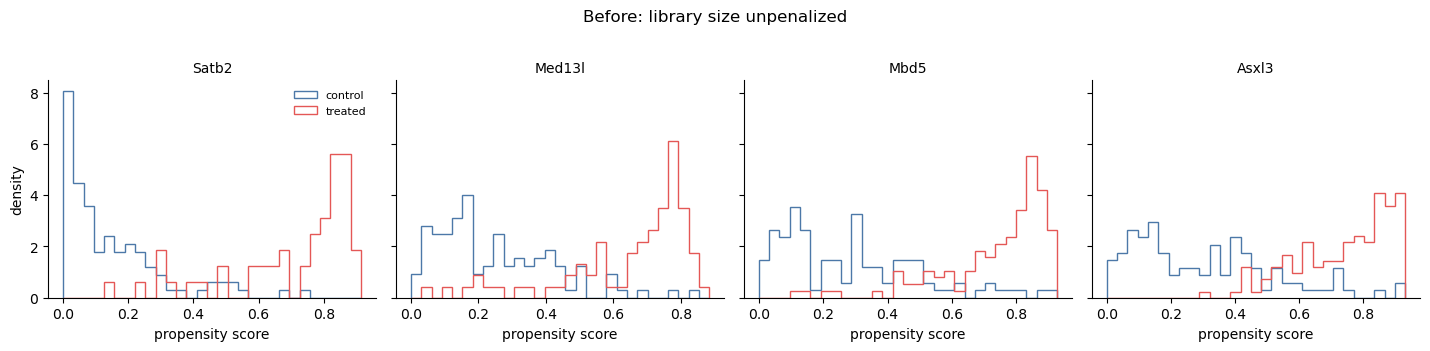

In [7]:
ps_focus = support_before.nsmallest(4, 'overlap_ratio').index.tolist()
print('weakest overlap:', ps_focus)

def overlap_panels(pi, title):
    ctrl_mask = A_np.sum(axis=1) == 0
    fig, axes = plt.subplots(1, len(ps_focus), figsize=(3.6 * len(ps_focus), 3.4), sharey=True)
    for ax, pert in zip(np.atleast_1d(axes), ps_focus):
        j = pert_names.index(pert)
        treated = A_np[:, j] == 1
        bins = np.linspace(0, max(pi[ctrl_mask | treated, j].max(), 1e-3), 30)
        ax.hist(pi[ctrl_mask, j], bins=bins, density=True, histtype='step',
                color='#4c78a8', label='control')
        ax.hist(pi[treated, j], bins=bins, density=True, histtype='step',
                color='#e45756', label='treated')
        ax.set_title(pert, fontsize=10)
        ax.set_xlabel('propensity score')
        for side in ('top', 'right'):
            ax.spines[side].set_visible(False)
    np.atleast_1d(axes)[0].set_ylabel('density')
    np.atleast_1d(axes)[0].legend(frameon=False, fontsize=8)
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    plt.show()

overlap_panels(pi_before, 'Before: library size unpenalized')

### Tuning the library-size penalty

`prep_causarray_data` appends standardized log library size to `X_A`. For a few perturbations it differs enough between the perturbed and control cells that the propensity model can tell them apart almost perfectly. Measured library size mixes capture depth with total RNA content, and these data do not identify which of the two drives a given arm's shift, so how much to adjust for it is a modelling choice rather than a settled one.

`tune_penalty_factor` penalizes **that coefficient alone**, and only for arms failing a pre-specified support check. Dropping the covariate is the infinite-penalty limit, so it bounds what any finite factor can achieve: the search evaluates that endpoint first, then returns the smallest factor meeting the target. The report shows both, so the penalty can be read against the limit rather than on its own.

Choose the target to match the failure. These arms lose histogram overlap while keeping most of their treated sample, so overlap is the target; a screen whose arms instead lose effective sample would target that.

In [8]:
penalty_factors, tuning_report = tune_penalty_factor(
    A_np, W_A, 'log_library_size',
    treatment_names=pert_names, covariate_names=propensity_names,
    trigger={'auc_gt': 0.9, 'ess_treated_fraction_lt': 0.5},
    target={'overlap_ratio_gt': 0.3},
    K=1, C=1.0, class_weight=None, random_state=0, verbose=True,
)
display(tuning_report[['treatment', 'penalty_factor', 'feasible', 'n_fits',
                       'overlap_ratio_unpenalized', 'overlap_ratio_chosen',
                       'overlap_ratio_dropped', 'auc_unpenalized', 'auc_chosen']]
        .sort_values('penalty_factor', ascending=False).round(3))

[tune_penalty_factor] 6 treatments triggered, 6 feasible, 48 fits


,treatment,penalty_factor,feasible,n_fits,overlap_ratio_unpenalized,overlap_ratio_chosen,overlap_ratio_dropped,auc_unpenalized,auc_chosen
3,Satb2,27.384,True,8,0.134,0.338,0.319,0.970,0.875
1,Mbd5,17.783,True,8,0.231,0.334,0.737,0.927,0.896
0,Asxl3,10.000,True,8,0.240,0.314,0.722,0.933,0.911
2,Med13l,8.660,True,8,0.221,0.308,0.574,0.909,0.888
4,Scn2a1,7.499,True,8,0.269,0.312,0.771,0.918,0.904
5,Upf3b,5.623,True,8,0.250,0.301,0.677,0.923,0.909


,penalty,overlap before,overlap after,AUC before,AUC after,treated ESS after
Satb2,27.384,0.134,0.338,0.970,0.875,0.681
Med13l,8.660,0.221,0.308,0.909,0.888,0.663
Mbd5,17.783,0.231,0.334,0.927,0.896,0.929
Asxl3,10.000,0.240,0.314,0.933,0.911,0.958


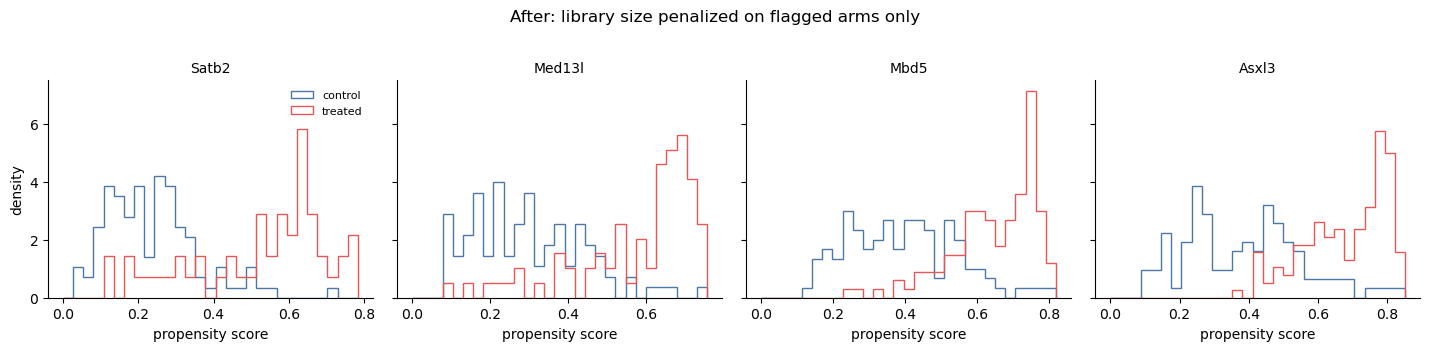

In [9]:
pi_after, refit_audit = refit_propensity_scores(
    A_np, W_A, pi_hat=pi_before.copy(),
    treatment_names=pert_names, covariate_names=propensity_names,
    penalty_factors_by_treatment=penalty_factors,
    K=1, C=1.0, class_weight=None, clip=None, random_state=0)

support_after = summarize_propensity_scores(
    A_np, pi_after, treatment_names=pert_names, clip_bounds=None).set_index('treatment')
display(pd.DataFrame({
    'penalty': pd.Series({k: v['log_library_size'] for k, v in penalty_factors.items()}),
    'overlap before': support_before['overlap_ratio'],
    'overlap after': support_after['overlap_ratio'],
    'AUC before': support_before['auc'],
    'AUC after': support_after['auc'],
    'treated ESS after': support_after['ess_treated_fraction'],
}).fillna({'penalty': 1.0}).loc[ps_focus].round(3))

overlap_panels(pi_after, 'After: library size penalized on flagged arms only')

### Treatment-association diagnostics

The summary compares each perturbation with shared controls using Spearman correlations and standardized mean differences. P-values are BH-adjusted across treatment–covariate pairs by default. Association alone does not identify a confounder or justify removing a covariate.

Library size and latent factors are derived from the measured transcriptome and may reflect perturbation responses as well as technical variation. Their causal role requires scientific justification. Factor labels refer to this fit; they need not retain the same meaning after refitting.


,treatment,covariate,covariate_type,n_control,n_treated,spearman_rho,pvalue,padj,standardized_mean_difference,constant,n_tests_in_family
217,Satb2,log_library_size,observed,106,51,-0.620601,4.352985e-18,1.388602e-15,-1.670432,False,319
133,Mbd5,log_library_size,observed,106,119,-0.525168,2.377952e-17,3.792833e-15,-1.196548,False,319
25,Asxl3,log_library_size,observed,106,130,-0.501171,2.061826e-16,2.192409e-14,-1.147867,False,319
325,Upf3b,log_library_size,observed,106,100,-0.524464,5.917208e-16,4.718973e-14,-1.193805,False,319
229,Scn2a1,log_library_size,observed,106,93,-0.479169,8.091610e-13,5.162447e-11,-1.070860,False,319
145,Med13l,log_library_size,observed,106,75,-0.491124,2.226940e-12,1.183990e-10,-1.072918,False,319
241,Setd2,log_library_size,observed,106,76,-0.450423,1.771080e-10,8.071064e-09,-0.971646,False,319
253,Setd5,log_library_size,observed,106,71,-0.438344,1.046791e-09,3.710293e-08,-0.952658,False,319
13,Ash1l,log_library_size,observed,106,122,-0.390531,1.003845e-09,3.710293e-08,-0.806900,False,319
109,Fbxo11,log_library_size,observed,106,111,-0.394344,1.730357e-09,5.519838e-08,-0.844210,False,319


,treatment,covariate,covariate_type,n_control,n_treated,spearman_rho,pvalue,padj,standardized_mean_difference,constant,n_tests_in_family
226,Satb2,U9,latent,106,51,-0.284792,0.000300,0.003831,-0.647524,False,319
223,Satb2,U6,latent,106,51,0.223272,0.004942,0.056300,0.420567,False,319
153,Med13l,U8,latent,106,75,0.203490,0.006005,0.065225,0.408630,False,319
220,Satb2,U3,latent,106,51,0.188161,0.018278,0.166595,0.402003,False,319
224,Satb2,U7,latent,106,51,0.233175,0.003293,0.038909,0.386768,False,319
222,Satb2,U5,latent,106,51,0.200165,0.011954,0.119164,0.371945,False,319
345,Wac,U8,latent,106,85,0.153050,0.034534,0.282472,0.302164,False,319
334,Upf3b,U9,latent,106,100,-0.166764,0.016587,0.160338,-0.301755,False,319
141,Mbd5,U8,latent,106,119,0.146131,0.028413,0.238519,0.294433,False,319
221,Satb2,U4,latent,106,51,0.152749,0.056150,0.416551,0.285548,False,319


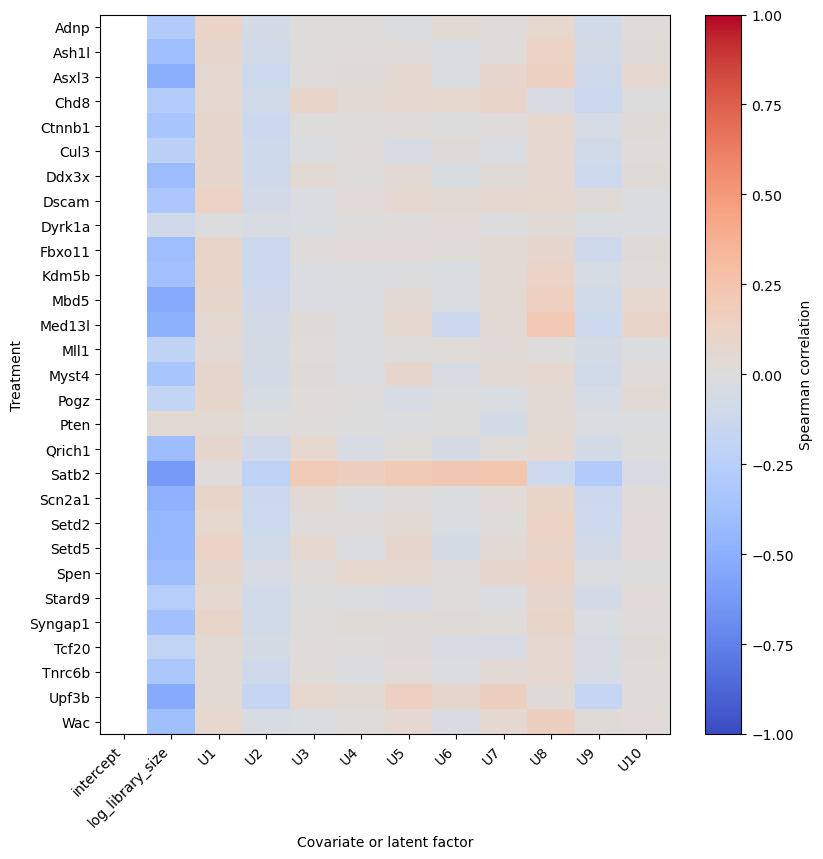

In [10]:
factor_names = [f'U{k + 1}' for k in range(U.shape[1])]
propensity_names = ['intercept', 'log_library_size', *factor_names]
propensity_types = ['observed', 'observed', *(['latent'] * U.shape[1])]
association_summary = summarize_treatment_associations(
    A, W_A, covariate_names=propensity_names,
    covariate_types=propensity_types,
)
observed_associations = association_summary.query("covariate_type == 'observed' and not constant")
latent_associations = association_summary.query("covariate_type == 'latent'").copy()
display(observed_associations.sort_values('padj').head(10))
display(
    latent_associations.assign(abs_smd=lambda frame: frame['standardized_mean_difference'].abs())
    .sort_values('abs_smd', ascending=False).drop(columns='abs_smd').head(10)
)
fig, ax = plot_treatment_associations(association_summary)
plt.show()

## Estimation and results


### Estimate log-fold changes

`LFC` combines outcome predictions and propensity scores to estimate adjusted log-fold changes. Reuse the GCATE size factors so both stages use the same normalization. Inference uses the AIPW influence-function variance with small-sample adjustments and a size-factor-aware Poisson variance floor; see the `LFC` documentation for details.


In [11]:
offsets = np.log(res_2['kwargs_glm']['size_factor']) # use the precomputed size factors
# pi_hat carries the tuned propensity from the section above, so the estimate and
# the diagnostics describe the same scores.
df_res, estimation = LFC(Y, np.c_[X, U], A, W_A, offset=offsets,
                         pi_hat=pi_after, verbose=True)

'Estimating LFC...'
{'a': 29, 'd': 11, 'd_A': 12, 'estimands': 'LFC', 'n': 2926, 'p': 3221}
{'offset': array([-0.63123664, -0.13510128,  0.20175377, ..., -0.58092607,
       -0.31435661, -0.25029351]),
 'random_state': 0,
 'verbose': True}
'Fit outcome models...'
'Fitting nb GLM (structured, 11 covariates + 29 treatments)...'


'Estimating AIPW mean...'


  0%|          | 0/29 [00:00<?, ?it/s]

 17%|█▋        | 5/29 [00:00<00:00, 49.62it/s]

 34%|███▍      | 10/29 [00:00<00:00, 39.34it/s]

 52%|█████▏    | 15/29 [00:00<00:00, 43.05it/s]

 72%|███████▏  | 21/29 [00:00<00:00, 46.06it/s]

 93%|█████████▎| 27/29 [00:00<00:00, 48.09it/s]

100%|██████████| 29/29 [00:00<00:00, 47.08it/s]

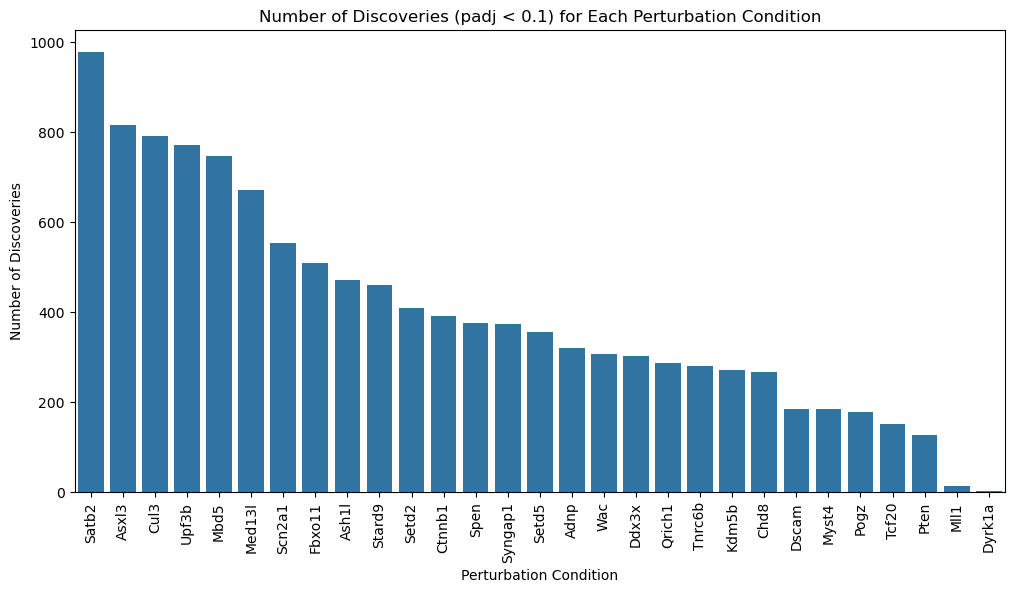

Total significant gene-perturbation pairs (padj < 0.1): 11,545
Perturbation  Count
       Satb2    979
       Asxl3    816
        Cul3    792
       Upf3b    772
        Mbd5    748
      Med13l    672
      Scn2a1    553
      Fbxo11    510
       Ash1l    472
      Stard9    461
       Setd2    408
      Ctnnb1    391
        Spen    375
     Syngap1    374
       Setd5    356
        Adnp    320
         Wac    306
       Ddx3x    301
      Qrich1    287
      Tnrc6b    280
       Kdm5b    270
        Chd8    267
       Dscam    183
       Myst4    183
        Pogz    178
       Tcf20    150
        Pten    127
        Mll1     13
      Dyrk1a      1


,negative_fraction,median_tau,significant,significant_negative,significant_positive
trt,,,,,
Scn2a1,0.677740,-0.081335,553,456,97
Med13l,0.676188,-0.103299,672,515,157
Mbd5,0.670599,-0.079192,748,586,162
Setd5,0.669047,-0.087442,356,291,65
Upf3b,0.655697,-0.080146,772,617,155
Satb2,0.652903,-0.127432,979,720,259
Chd8,0.650419,-0.061585,267,205,62
Qrich1,0.649798,-0.068327,287,228,59
Asxl3,0.649488,-0.075428,816,634,182


In [12]:
# Filter the results for significant discoveries
significant_discoveries = df_res[df_res['padj'] < 0.1]

# Count the number of discoveries for each perturbation condition
discovery_counts = significant_discoveries['trt'].value_counts().reset_index()
discovery_counts.columns = ['Perturbation', 'Count']

# Plot the number of discoveries for each perturbation condition
plt.figure(figsize=(12, 6))
sns.barplot(data=discovery_counts, x='Perturbation', y='Count')
plt.xticks(rotation=90)
plt.title('Number of Discoveries (padj < 0.1) for Each Perturbation Condition')
plt.xlabel('Perturbation Condition')
plt.ylabel('Number of Discoveries')
plt.show()
print(f"Total significant gene-perturbation pairs (padj < 0.1): {len(significant_discoveries):,}")
print(discovery_counts.to_string(index=False))

direction = df_res.assign(
    significant=df_res['padj'] < 0.1,
    significant_negative=(df_res['padj'] < 0.1) & (df_res['tau'] < 0),
    significant_positive=(df_res['padj'] < 0.1) & (df_res['tau'] > 0),
).groupby('trt').agg(
    negative_fraction=('tau', lambda value: (value < 0).mean()),
    median_tau=('tau', 'median'),
    significant=('significant', 'sum'),
    significant_negative=('significant_negative', 'sum'),
    significant_positive=('significant_positive', 'sum'),
).sort_values('negative_fraction', ascending=False)
display(direction)

### Covariate filtering for one treatment

The tuner above adjusts how strongly one coefficient is penalized. `refit_propensity_scores` can also remove a covariate from a single treatment's propensity design, which is a different operation: a penalty shrinks a coefficient the data cannot support, whereas dropping asserts the covariate does not belong in that model.

Satb2 is used here to show the mechanics. The variants remove U9 or U8, raise the library-size penalty, and shrink every coefficient with a smaller `C`. They are illustrative settings for reading the audit output, not candidates to choose among by discovery count; recheck factor associations after refitting.

Only Satb2's scores change. Out-of-fold fits supply the diagnostics, while separate in-sample fits supply the variant LFC estimates using the primary fit's cached outcome predictions. Removing a factor here does not remove it from the outcome model.

,model,n_retained,penalty_factors,degenerate_design,score_std
0,drop U9,11,{},False,0.304
0,drop U8,11,{},False,0.300
0,10x library penalty,12,{'log_library_size': 10.0},False,0.221
0,Satb2 C=0.1,12,{},False,0.221


,model,overlap_ratio,outside_overlap_fraction,ess_control_fraction,ess_treated_fraction,brier_score
18,all factors,0.250,0.223,0.483,0.537,0.099
18,drop U9,0.261,0.229,0.279,0.410,0.107
18,drop U8,0.239,0.255,0.341,0.525,0.103
18,10x library penalty,0.349,0.051,0.814,0.585,0.135
18,Satb2 C=0.1,0.279,0.019,0.751,0.753,0.136


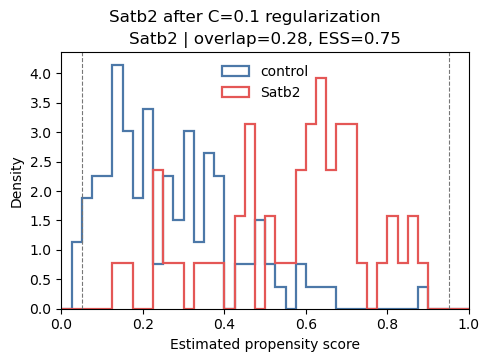

  0%|          | 0/29 [00:00<?, ?it/s]

 17%|█▋        | 5/29 [00:00<00:00, 49.58it/s]

 34%|███▍      | 10/29 [00:00<00:00, 40.21it/s]

 59%|█████▊    | 17/29 [00:00<00:00, 49.07it/s]

 83%|████████▎ | 24/29 [00:00<00:00, 54.75it/s]

...

 41%|████▏     | 12/29 [00:00<00:00, 52.69it/s]

 66%|██████▌   | 19/29 [00:00<00:00, 57.30it/s]

 90%|████████▉ | 26/29 [00:00<00:00, 60.07it/s]

100%|██████████| 29/29 [00:00<00:00, 57.80it/s]

,model,effect_correlation,median_absolute_change,discoveries,discoveries_all
0,drop U9,0.967,0.032,1063,979
1,drop U8,0.944,0.043,1149,979
2,10x library penalty,0.951,0.015,1106,979
3,Satb2 C=0.1,0.946,0.030,1119,979


In [13]:
# Four treatment-specific alternatives for Satb2. Each refits Satb2 alone and
# leaves other perturbations' scores unchanged. Factor labels belong to this fit.
satb2_variants = {
    'drop U9': dict(drop_by_treatment={'Satb2': ['U9']}),
    'drop U8': dict(drop_by_treatment={'Satb2': ['U8']}),
    '10x library penalty': dict(
        penalty_factors_by_treatment={'Satb2': {'log_library_size': 10}}),
    'Satb2 C=0.1': dict(drop_by_treatment={'Satb2': []}, C=0.1),
}


def refit_satb2(pi_hat, K, **kwargs):
    return refit_propensity_scores(
        A, W_A, pi_hat=pi_hat, covariate_names=propensity_names, K=K,
        random_state=0, **kwargs,
    )


# Out-of-fold scores, used only for the overlap diagnostics.
oof_variants, audits = {}, []
for name, options in satb2_variants.items():
    scores, audit = refit_satb2(pi_oof, 5, **options)
    oof_variants[name] = scores
    audits.append(audit.assign(model=name))
display(
    pd.concat(audits)
    [['model', 'n_retained', 'penalty_factors', 'degenerate_design', 'score_std']]
    .round(3)
)

satb2_overlap = pd.concat([
    summarize_propensity_scores(A, scores, clip_bounds=None)
    .query("treatment == 'Satb2'").assign(model=name)
    for name, scores in {'all factors': pi_oof, **oof_variants}.items()
])[['model', 'overlap_ratio', 'outside_overlap_fraction',
    'ess_control_fraction', 'ess_treated_fraction', 'brier_score']]
display(satb2_overlap.round(3))

fig, axes, _ = plot_propensity_scores(
    A, oof_variants['Satb2 C=0.1'], treatments=['Satb2'], clip_bounds=None,
)
fig.suptitle('Satb2 after C=0.1 regularization', y=1.02)
plt.show()

# Analysis scores reuse the cached outcome model, so no outcome model is refitted.
satb2_effects = (
    df_res.query("trt == 'Satb2'")[['gene_names', 'tau', 'padj']]
    .rename(columns={'tau': 'tau_all', 'padj': 'padj_all'})
)
comparison = []
for name, options in satb2_variants.items():
    pi_analysis, _ = refit_satb2(estimation['pi_hat_raw'], 1, **options)
    df_alt, _ = LFC(
        Y, np.c_[X, U], A, W_A, offset=offsets,
        Y_hat=estimation['Y_hat'], pi_hat=pi_analysis,
    )
    merged = satb2_effects.merge(
        df_alt.query("trt == 'Satb2'")[['gene_names', 'tau', 'padj']], on='gene_names',
    )
    comparison.append({
        'model': name,
        'effect_correlation': merged[['tau_all', 'tau']].corr().iloc[0, 1],
        'median_absolute_change': (merged['tau_all'] - merged['tau']).abs().median(),
        'discoveries': int((merged['padj'] < 0.1).sum()),
    })
display(
    pd.DataFrame(comparison)
    .assign(discoveries_all=int((satb2_effects['padj_all'] < 0.1).sum()))
    .round(3)
)

### Reading the filtering comparison

The saved examples show that removing a factor can reduce control ESS even when histogram overlap improves, and that stronger penalties give less concentrated weights at a worse out-of-fold Brier score. Effect estimates stay broadly correlated with the primary fit while some discovery decisions change.

That is a tradeoff, not evidence that one variant is more trustworthy. Read prediction, weight concentration, and effect stability together, and do not pick a design to raise overlap or discovery counts. Keep factor removal for cases with a scientific reason to change the adjustment set, and re-examine the pattern in a new run rather than carrying a fixed `C` across datasets.